In [3]:
#*******************************************************************************
# Assignment: hw4.ipynb
# Author: Harris Hamid
# Date: 10/20/2025
# Description: Homework 4
# Pledge: I pledge my honor that I have abided by the Stevens Honor System
#******************************************************************************/

In [4]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.kernel_ridge import KernelRidge
from sklearn.svm import SVR
from sklearn.metrics import r2_score
import time
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import mean_squared_error
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Data Processing
df_test = pd.read_csv('processed_training_data_.csv')
df_train = pd.read_csv('processed_training_data_.csv')

X_train = df_train.drop('Salary', axis=1)
y_train = df_train['Salary']

X_test = df_test.drop('Salary', axis=1)
y_test = df_test['Salary']


In [5]:
# # Corrected Data Preproccessing from Assignemtn 3
# df = pd.read_csv("Hitters.csv")

# print(f"Original dataset: {df.shape}")

# # Remove observations with missing target variable
# df_clean = df.dropna(subset=['Salary']).copy()
# print(f"After removing missing salaries: {df_clean.shape}")

# # Safe division function to prevent division by zero errors
# def safe_divide(numerator, denominator, default=0):
#     return np.where(denominator != 0, numerator / denominator, default)

# # Feature Engineering
# df_clean['BattingAvg'] = safe_divide(df_clean['Hits'], df_clean['AtBat'])
# df_clean['HomeRunRate'] = safe_divide(df_clean['HmRun'], df_clean['AtBat'])
# df_clean['OnBasePercentage'] = safe_divide(df_clean['Hits'] + df_clean['Walks'], df_clean['AtBat'])
# df_clean['RBIRate'] = safe_divide(df_clean['RBI'], df_clean['AtBat'])
# df_clean['CareerBattingAvg'] = safe_divide(df_clean['CHits'], df_clean['CAtBat'])
# df_clean['CareerHomeRunRate'] = safe_divide(df_clean['CHmRun'], df_clean['CAtBat'])
# df_clean['ProductivityIndex'] = df_clean['Hits'] + df_clean['HmRun'] + df_clean['RBI']
# df_clean['CareerProductivity'] = df_clean['CHits'] + df_clean['CHmRun'] + df_clean['CRBI']
# df_clean['FieldingPercentage'] = safe_divide(
#     df_clean['PutOuts'] + df_clean['Assists'],
#     df_clean['PutOuts'] + df_clean['Assists'] + df_clean['Errors']
# )

# print("Engineered 9 new features")

# # Proper categorical encoding (instead of dropping)
# categorical_cols = ['League', 'Division', 'NewLeague']
# for col in categorical_cols:
#     dummies = pd.get_dummies(df_clean[col], prefix=col, drop_first=True)
#     df_clean = pd.concat([df_clean, dummies], axis=1)

# df_clean = df_clean.drop(categorical_cols, axis=1)
# print(f"After categorical encoding: {df_clean.shape}")

# # Separate features and target
# y = df_clean['Salary']
# X = df_clean.drop('Salary', axis=1)

# # Train-test split before any feature selection
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.3, random_state=42,
#     stratify=pd.qcut(y, q=3, duplicates='drop')
# )
# print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")

# # Handle missing values
# imputer = SimpleImputer(strategy='median')
# X_train_imputed = pd.DataFrame(
#     imputer.fit_transform(X_train),
#     columns=X_train.columns,
#     index=X_train.index
# )
# X_test_imputed = pd.DataFrame(
#     imputer.transform(X_test),
#     columns=X_test.columns,
#     index=X_test.index
# )

# # Feature selection for no data leakage, only traning data used)
# selector = SelectKBest(score_func=f_regression, k=15)
# X_train_selected = selector.fit_transform(X_train_imputed, y_train)
# X_test_selected = selector.transform(X_test_imputed)

# selected_features = X_train_imputed.columns[selector.get_support()].tolist()
# print(f"Selected {len(selected_features)} features")

# # Feature scaling
# scaler = StandardScaler()
# X_train_final = scaler.fit_transform(X_train_selected)
# X_test_final = scaler.transform(X_test_selected)

# print(f"Final shapes - Train: {X_train_final.shape}, Test: {X_test_final.shape}")

# # Save processed data
# train_df = pd.DataFrame(X_train_final, columns=[f"feature_{i}" for i in range(X_train_final.shape[1])])
# train_df['Salary'] = y_train.values

# test_df = pd.DataFrame(X_test_final, columns=[f"feature_{i}" for i in range(X_test_final.shape[1])])
# test_df['Salary'] = y_test.values

# train_df.to_csv('fixed_training.csv', index=False)
# test_df.to_csv('fixed_testing.csv', index=False)


In [6]:
# Neural Network:
nn_model = MLPRegressor(max_iter=10000, activation='relu', hidden_layer_sizes=(200, 100),
                        solver='adam', learning_rate='constant', learning_rate_init=0.01)
nn_model.fit(X_train, y_train)

print("Neural Network:")
print(f"Train R²: {r2_score(y_train, nn_model.predict(X_train))}")
print(f"Test R²: {r2_score(y_test, nn_model.predict(X_test))}")

ValueError: could not convert string to float: 'N'

Neural Network Tuning
Features: 2, Time: 53.5s, Test R²: 0.257
Features: 4, Time: 56.0s, Test R²: 0.267
Features: 6, Time: 54.8s, Test R²: 0.266
Features: 8, Time: 52.9s, Test R²: 0.370
Features: 10, Time: 53.6s, Test R²: 0.408

Curse of Dimensionality Plot


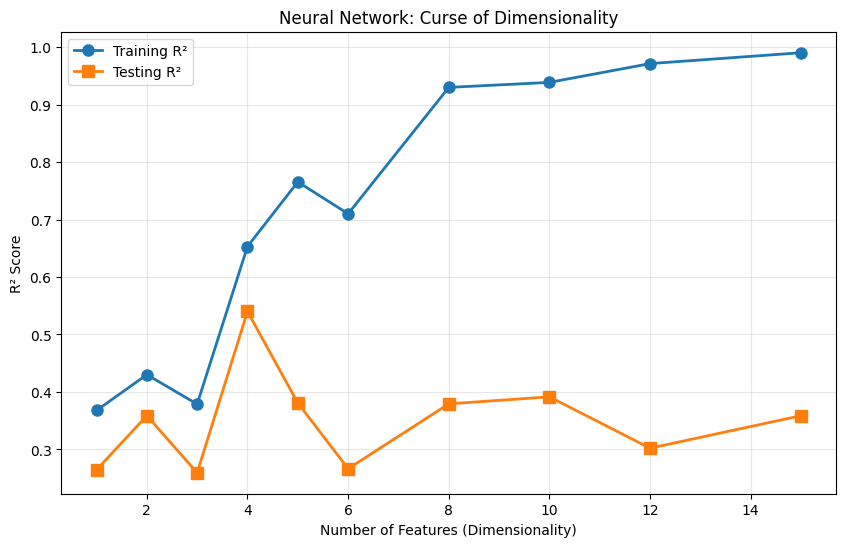


Bias-Variance Tradeoff Plot


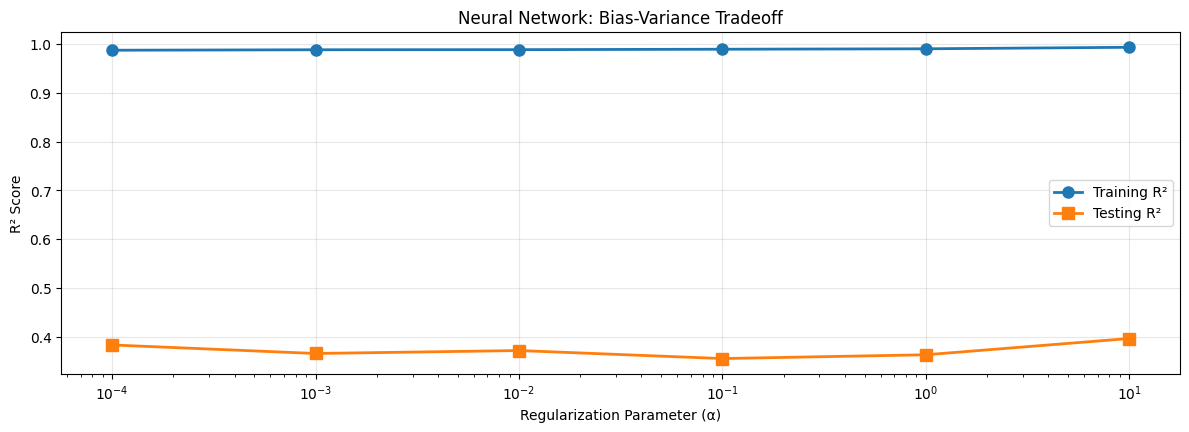

In [ ]:
print("Neural Network Tuning")

nn_param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (100, 50)],
    'alpha': [0.001, 0.01, 0.1],
    'learning_rate_init': [0.001, 0.01]
}

features_to_test = [2, 4, 6, 8, 10]
nn_times = []
nn_train_scores = []
nn_test_scores = []

for n_features in features_to_test:
    if n_features > X_train.shape[1]:
        n_features = X_train.shape[1]

    # Select features
    selector = SelectKBest(f_regression, k=n_features)
    X_train_selected = selector.fit_transform(X_train, y_train)
    X_test_selected = selector.transform(X_test)

    # Time the hyperparameter tuning
    start_time = time.time()

    # GridSearchCV
    nn_grid = GridSearchCV(
        MLPRegressor(max_iter=3000, random_state=42),
        nn_param_grid,
        cv=3,  # 3-fold cross validation
        scoring='r2',
        n_jobs=-1
    )

    nn_grid.fit(X_train_selected, y_train)

    end_time = time.time()
    tuning_time = end_time - start_time
    nn_times.append(tuning_time)

    # Get best model scores
    best_nn = nn_grid.best_estimator_
    nn_train_scores.append(r2_score(y_train, best_nn.predict(X_train_selected)))
    nn_test_scores.append(r2_score(y_test, best_nn.predict(X_test_selected)))

    print(f"Features: {n_features}, Time: {tuning_time:.1f}s, Test R²: {nn_test_scores[-1]:.3f}")

# =============================
# CURSE OF DIMENSIONALITY PLOT
# =============================
print("\nCurse of Dimensionality Plot")

# Useing a wider range of features
curse_features = [1, 2, 3, 4, 5, 6, 8, 10, 12, X_train.shape[1]]
curse_train_scores = []
curse_test_scores = []

for n_features in curse_features:
    if n_features > X_train.shape[1]:
        n_features = X_train.shape[1]

    # Feature selection
    selector = SelectKBest(f_regression, k=n_features)
    X_train_selected = selector.fit_transform(X_train, y_train)
    X_test_selected = selector.transform(X_test)

    # Train with fixed hyperparametrs for fair comparison
    nn_curse = MLPRegressor(
        hidden_layer_sizes=(100, 50),
        alpha=0.01,
        max_iter=3000,
        random_state=42
    )
    nn_curse.fit(X_train_selected, y_train)

    curse_train_scores.append(r2_score(y_train, nn_curse.predict(X_train_selected)))
    curse_test_scores.append(r2_score(y_test, nn_curse.predict(X_test_selected)))

plt.figure(figsize=(10, 6))
plt.plot(curse_features, curse_train_scores, 'o-', label='Training R²', linewidth=2, markersize=8)
plt.plot(curse_features, curse_test_scores, 's-', label='Testing R²', linewidth=2, markersize=8)
plt.xlabel('Number of Features (Dimensionality)')
plt.ylabel('R² Score')
plt.title('Neural Network: Curse of Dimensionality')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ============================
# BIAS-VARIANCE TRADEOFF PLOT
# ============================
print("\nBias-Variance Tradeoff Plot")

# Test different regularization valuesto show bias-variance tradeoff
alpha_values = [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0]
bias_train_scores = []
bias_test_scores = []
bias_variance_gap = []

for alpha in alpha_values:
    train_preds = []
    test_preds = []

    for seed in range(5):  # 5 different random initializations
        nn_bias = MLPRegressor(
            hidden_layer_sizes=(100, 50),
            alpha=alpha,
            max_iter=3000,
            random_state=seed
        )
        nn_bias.fit(X_train, y_train)

        train_preds.append(nn_bias.predict(X_train))
        test_preds.append(nn_bias.predict(X_test))

    # Average performance across random initializations
    avg_train_r2 = np.mean([r2_score(y_train, pred) for pred in train_preds])
    avg_test_r2 = np.mean([r2_score(y_test, pred) for pred in test_preds])

    bias_train_scores.append(avg_train_r2)
    bias_test_scores.append(avg_test_r2)
    bias_variance_gap.append(avg_train_r2 - avg_test_r2)

plt.figure(figsize=(12, 8))

# R² scores vs regularization
plt.subplot(2, 1, 1)
plt.semilogx(alpha_values, bias_train_scores, 'o-', label='Training R²', linewidth=2, markersize=8)
plt.semilogx(alpha_values, bias_test_scores, 's-', label='Testing R²', linewidth=2, markersize=8)
plt.xlabel('Regularization Parameter (α)')
plt.ylabel('R² Score')
plt.title('Neural Network: Bias-Variance Tradeoff')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# K-Nearest Neighbors
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train, y_train)

print("K-Nearest Neighbors:")
print(f"Train R²: {r2_score(y_train, knn_model.predict(X_train))}")
print(f"Test R²: {r2_score(y_test, knn_model.predict(X_test))}")


K-Nearest Neighbors:
Train R²: 0.6047340844873506
Test R²: 0.5379089107418903


K-Nearest Neighbors
Features: 2, Time: 0.2s, Test R²: 0.401
Features: 4, Time: 0.1s, Test R²: 0.394
Features: 6, Time: 0.2s, Test R²: 0.445
Features: 8, Time: 0.2s, Test R²: 0.458
Features: 10, Time: 0.1s, Test R²: 0.504
Features: 15, Time: 0.1s, Test R²: 0.528

Curse of Dimensionality Plot


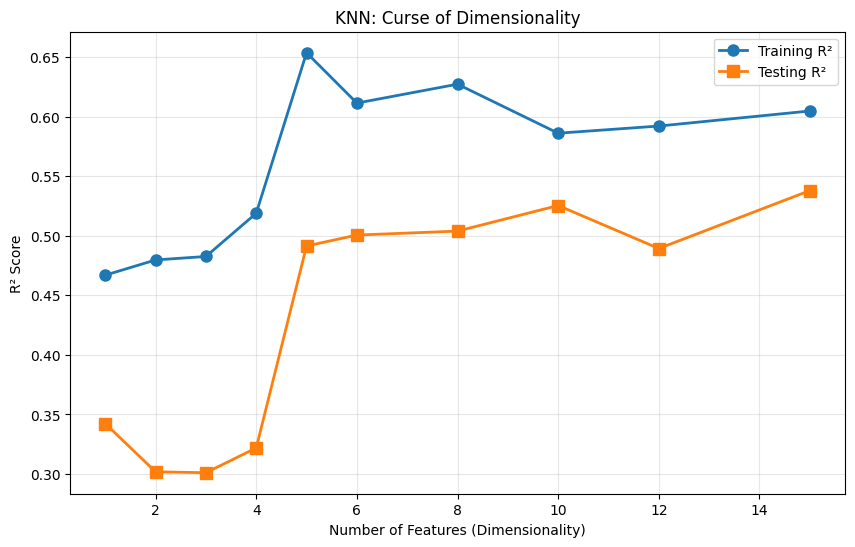


Bias-Variance Tradeoff Plot


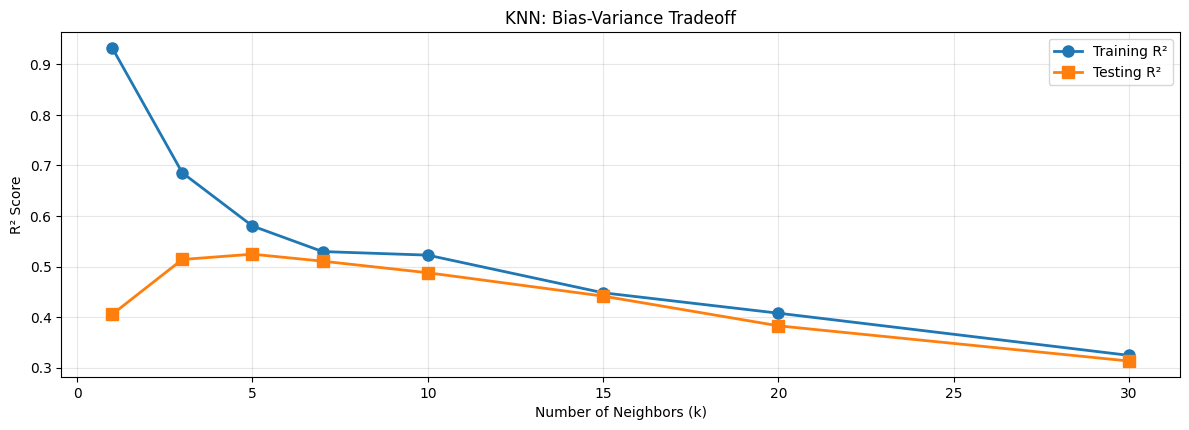

In [ ]:
print("K-Nearest Neighbors")

knn_param_grid = {
    'n_neighbors': [3, 5, 7, 10, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

features_to_test = [2, 4, 6, 8, 10, X_train.shape[1]]
knn_times = []
knn_train_scores = []
knn_test_scores = []

for n_features in features_to_test:
    if n_features > X_train.shape[1]:
        n_features = X_train.shape[1]

    # Select features
    selector = SelectKBest(f_regression, k=n_features)
    X_train_selected = selector.fit_transform(X_train, y_train)
    X_test_selected = selector.transform(X_test)

    # Time the hyperparameter tuning
    start_time = time.time()

    # GridSearchCV
    knn_grid = GridSearchCV(
        KNeighborsRegressor(),
        knn_param_grid,
        cv=3,  # 3-fold cross validation
        scoring='r2',
        n_jobs=-1
    )

    knn_grid.fit(X_train_selected, y_train)

    end_time = time.time()
    tuning_time = end_time - start_time
    knn_times.append(tuning_time)

    # Get best model scores
    best_knn = knn_grid.best_estimator_
    knn_train_scores.append(r2_score(y_train, best_knn.predict(X_train_selected)))
    knn_test_scores.append(r2_score(y_test, best_knn.predict(X_test_selected)))

    print(f"Features: {n_features}, Time: {tuning_time:.1f}s, Test R²: {knn_test_scores[-1]:.3f}")

# =============================
# CURSE OF DIMENSIONALITY PLOT
# =============================
print("\nCurse of Dimensionality Plot")

curse_features = [1, 2, 3, 4, 5, 6, 8, 10, 12, X_train.shape[1]]
curse_train_scores = []
curse_test_scores = []

for n_features in curse_features:
    if n_features > X_train.shape[1]:
        n_features = X_train.shape[1]

    # Feature selection
    selector = SelectKBest(f_regression, k=n_features)
    X_train_selected = selector.fit_transform(X_train, y_train)
    X_test_selected = selector.transform(X_test)

    # Train with fixed hyperparameters for fair comparison
    knn_curse = KNeighborsRegressor(n_neighbors=5, weights='uniform')
    knn_curse.fit(X_train_selected, y_train)

    curse_train_scores.append(r2_score(y_train, knn_curse.predict(X_train_selected)))
    curse_test_scores.append(r2_score(y_test, knn_curse.predict(X_test_selected)))

plt.figure(figsize=(10, 6))
plt.plot(curse_features, curse_train_scores, 'o-', label='Training R²', linewidth=2, markersize=8)
plt.plot(curse_features, curse_test_scores, 's-', label='Testing R²', linewidth=2, markersize=8)
plt.xlabel('Number of Features (Dimensionality)')
plt.ylabel('R² Score')
plt.title('KNN: Curse of Dimensionality')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ============================
# BIAS-VARIANCE TRADEOFF PLOT
# ============================
print("\nBias-Variance Tradeoff Plot")

# For KNN, we vary k (number of neighbors) to show bias-variance tradeoff
k_values = [1, 3, 5, 7, 10, 15, 20, 30]
bias_train_scores = []
bias_test_scores = []
bias_variance_gap = []

for k in k_values:
    train_r2_list = []
    test_r2_list = []

    # Use different random subsets for variance estimation
    for seed in range(5):
        np.random.seed(seed)
        # Small bootstrap sample to add variance
        indices = np.random.choice(len(X_train), size=int(0.9*len(X_train)), replace=False)
        X_bootstrap = X_train.iloc[indices]
        y_bootstrap = y_train.iloc[indices]

        knn_bias = KNeighborsRegressor(n_neighbors=k, weights='uniform')
        knn_bias.fit(X_bootstrap, y_bootstrap)

        train_r2_list.append(r2_score(y_train, knn_bias.predict(X_train)))
        test_r2_list.append(r2_score(y_test, knn_bias.predict(X_test)))

    # Average performance
    avg_train_r2 = np.mean(train_r2_list)
    avg_test_r2 = np.mean(test_r2_list)

    bias_train_scores.append(avg_train_r2)
    bias_test_scores.append(avg_test_r2)
    bias_variance_gap.append(avg_train_r2 - avg_test_r2)

plt.figure(figsize=(12, 8))

#1: R² scores vs k
plt.subplot(2, 1, 1)
plt.plot(k_values, bias_train_scores, 'o-', label='Training R²', linewidth=2, markersize=8)
plt.plot(k_values, bias_test_scores, 's-', label='Testing R²', linewidth=2, markersize=8)
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('R² Score')
plt.title('KNN: Bias-Variance Tradeoff')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# Kernal Ridge Regression
krr_model = KernelRidge( alpha=1, gamma=0.01)
krr_model.fit(X_train, y_train)

print("Kernal Ridge Regression:")
print(f"Train R²: {r2_score(y_train, krr_model.predict(X_train))}")
print(f"Test R²: {r2_score(y_test, krr_model.predict(X_test))}")


Kernal Ridge Regression:
Train R²: -0.7832034077458068
Test R²: -1.091078899907786


Kernel Ridge Regression
Features: 2, Time: 0.3s, Test R²: 0.306
Features: 4, Time: 0.3s, Test R²: 0.342
Features: 6, Time: 0.3s, Test R²: 0.377
Features: 8, Time: 0.3s, Test R²: 0.432
Features: 10, Time: 0.3s, Test R²: 0.427
Features: 15, Time: 0.3s, Test R²: 0.532

Curse of Dimensionality Plot


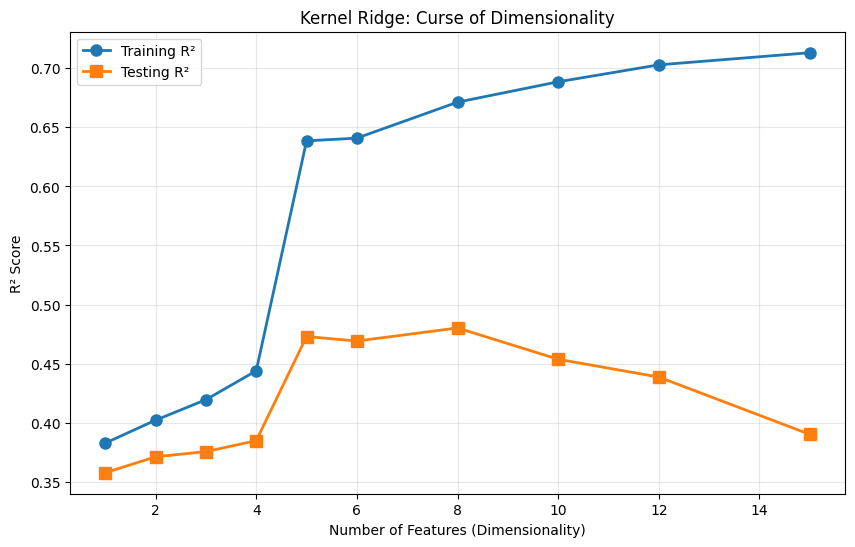


Bias-Variance Tradeoff Plot


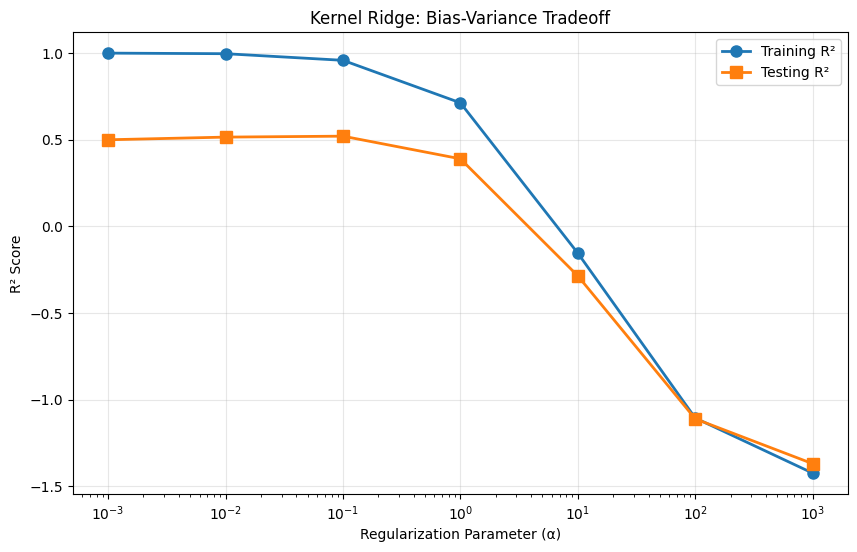

In [ ]:
print("Kernel Ridge Regression")

krr_param_grid = {
    'alpha': [0.1, 1.0, 10.0, 100.0],
    'gamma': [0.001, 0.01, 0.1, 1.0],
    'kernel': ['rbf', 'polynomial', 'linear']
}

features_to_test = [2, 4, 6, 8, 10, X_train.shape[1]]
krr_times = []
krr_train_scores = []
krr_test_scores = []

for n_features in features_to_test:
    if n_features > X_train.shape[1]:
        n_features = X_train.shape[1]

    # Select features
    selector = SelectKBest(f_regression, k=n_features)
    X_train_selected = selector.fit_transform(X_train, y_train)
    X_test_selected = selector.transform(X_test)

    # Time the hyperparameter tuning
    start_time = time.time()

    # GridSearchCV
    krr_grid = GridSearchCV(
        KernelRidge(),
        krr_param_grid,
        cv=3,  # 3-fold cross validation
        scoring='r2',
        n_jobs=-1
    )

    krr_grid.fit(X_train_selected, y_train)

    end_time = time.time()
    tuning_time = end_time - start_time
    krr_times.append(tuning_time)

    # Get best model scores
    best_krr = krr_grid.best_estimator_
    krr_train_scores.append(r2_score(y_train, best_krr.predict(X_train_selected)))
    krr_test_scores.append(r2_score(y_test, best_krr.predict(X_test_selected)))

    print(f"Features: {n_features}, Time: {tuning_time:.1f}s, Test R²: {krr_test_scores[-1]:.3f}")

# =============================
# CURSE OF DIMENSIONALITY PLOT
# =============================
print("\nCurse of Dimensionality Plot")

curse_features = [1, 2, 3, 4, 5, 6, 8, 10, 12, X_train.shape[1]]
curse_train_scores = []
curse_test_scores = []

for n_features in curse_features:
    if n_features > X_train.shape[1]:
        n_features = X_train.shape[1]

    # Feature selection
    selector = SelectKBest(f_regression, k=n_features)
    X_train_selected = selector.fit_transform(X_train, y_train)
    X_test_selected = selector.transform(X_test)

    # Train with fixed hyperparameters for fair comparison
    krr_curse = KernelRidge(alpha=1.0, gamma=0.1, kernel='rbf')
    krr_curse.fit(X_train_selected, y_train)

    curse_train_scores.append(r2_score(y_train, krr_curse.predict(X_train_selected)))
    curse_test_scores.append(r2_score(y_test, krr_curse.predict(X_test_selected)))

plt.figure(figsize=(10, 6))
plt.plot(curse_features, curse_train_scores, 'o-', label='Training R²', linewidth=2, markersize=8)
plt.plot(curse_features, curse_test_scores, 's-', label='Testing R²', linewidth=2, markersize=8)
plt.xlabel('Number of Features (Dimensionality)')
plt.ylabel('R² Score')
plt.title('Kernel Ridge: Curse of Dimensionality')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ============================
# BIAS-VARIANCE TRADEOFF PLOT
# ============================
print("\nBias-Variance Tradeoff Plot")

# vary alpha to show bias-variance tradeoff
alpha_values = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
bias_train_scores = []
bias_test_scores = []

for alpha in alpha_values:
    krr_bias = KernelRidge(alpha=alpha, gamma=0.1, kernel='rbf')
    krr_bias.fit(X_train, y_train)

    bias_train_scores.append(r2_score(y_train, krr_bias.predict(X_train)))
    bias_test_scores.append(r2_score(y_test, krr_bias.predict(X_test)))

plt.figure(figsize=(10, 6))
plt.semilogx(alpha_values, bias_train_scores, 'o-', label='Training R²', linewidth=2, markersize=8)
plt.semilogx(alpha_values, bias_test_scores, 's-', label='Testing R²', linewidth=2, markersize=8)
plt.xlabel('Regularization Parameter (α)')
plt.ylabel('R² Score')
plt.title('Kernel Ridge: Bias-Variance Tradeoff')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# SVM
svm_model = SVR(kernel='rbf', C=100, gamma=0.1)
svm_model.fit(X_train, y_train)

print("SVM:")
print(f"Train R²: {r2_score(y_train, svm_model.predict(X_train))}")
print(f"Test R²: {r2_score(y_test, svm_model.predict(X_test))}")


SVM:
Train R²: 0.4520968295620833
Test R²: 0.40822367534053594


Support Vector Machine


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
48 fits failed out of a total of 144.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
27 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/

Features: 2, Time: 0.2s, Test R²: 0.389


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
48 fits failed out of a total of 144.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
26 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/

Features: 4, Time: 0.2s, Test R²: 0.411


...

Features: 8, Time: 0.3s, Test R²: 0.472


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
48 fits failed out of a total of 144.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
29 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/

Features: 10, Time: 0.3s, Test R²: 0.486


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
48 fits failed out of a total of 144.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/

Features: 15, Time: 0.3s, Test R²: 0.527

Curse of Dimensionality Plot


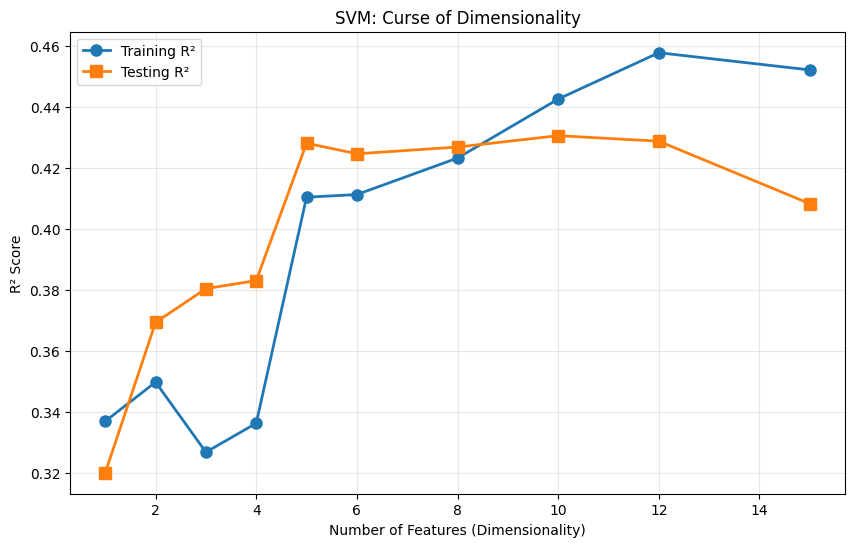


Bias-Variance Tradeoff Plot


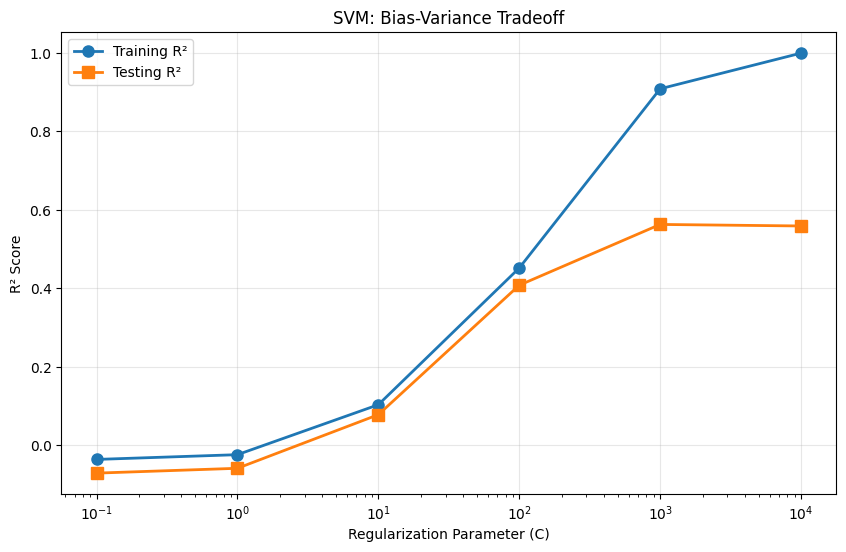

In [ ]:
print("Support Vector Machine")

svm_param_grid = {
    'C': [1, 10, 100, 1000],
    'gamma': [0.001, 0.01, 0.1, 1.0],
    'kernel': ['rbf', 'polynomial', 'linear']
}

features_to_test = [2, 4, 6, 8, 10, X_train.shape[1]]
svm_times = []
svm_train_scores = []
svm_test_scores = []

for n_features in features_to_test:
    if n_features > X_train.shape[1]:
        n_features = X_train.shape[1]

    # Select features
    selector = SelectKBest(f_regression, k=n_features)
    X_train_selected = selector.fit_transform(X_train, y_train)
    X_test_selected = selector.transform(X_test)

    # Time the hyperparameter tuning
    start_time = time.time()

    # GridSearchCV
    svm_grid = GridSearchCV(
        SVR(),
        svm_param_grid,
        cv=3,  # 3-fold cross validation
        scoring='r2',
        n_jobs=-1
    )

    svm_grid.fit(X_train_selected, y_train)

    end_time = time.time()
    tuning_time = end_time - start_time
    svm_times.append(tuning_time)

    # Get best model scores
    best_svm = svm_grid.best_estimator_
    svm_train_scores.append(r2_score(y_train, best_svm.predict(X_train_selected)))
    svm_test_scores.append(r2_score(y_test, best_svm.predict(X_test_selected)))

    print(f"Features: {n_features}, Time: {tuning_time:.1f}s, Test R²: {svm_test_scores[-1]:.3f}")

# =============================
# CURSE OF DIMENSIONALITY PLOT
# =============================
print("\nCurse of Dimensionality Plot")

curse_features = [1, 2, 3, 4, 5, 6, 8, 10, 12, X_train.shape[1]]
curse_train_scores = []
curse_test_scores = []

for n_features in curse_features:
    if n_features > X_train.shape[1]:
        n_features = X_train.shape[1]

    # Feature selection
    selector = SelectKBest(f_regression, k=n_features)
    X_train_selected = selector.fit_transform(X_train, y_train)
    X_test_selected = selector.transform(X_test)

    # Train with fixed hyperparameters for fair comparison
    svm_curse = SVR(C=100, gamma=0.1, kernel='rbf')
    svm_curse.fit(X_train_selected, y_train)

    curse_train_scores.append(r2_score(y_train, svm_curse.predict(X_train_selected)))
    curse_test_scores.append(r2_score(y_test, svm_curse.predict(X_test_selected)))

plt.figure(figsize=(10, 6))
plt.plot(curse_features, curse_train_scores, 'o-', label='Training R²', linewidth=2, markersize=8)
plt.plot(curse_features, curse_test_scores, 's-', label='Testing R²', linewidth=2, markersize=8)
plt.xlabel('Number of Features (Dimensionality)')
plt.ylabel('R² Score')
plt.title('SVM: Curse of Dimensionality')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ============================
# BIAS-VARIANCE TRADEOFF PLOT
# ============================
print("\nBias-Variance Tradeoff Plot")

# vary C to show bias-variance tradeoff
C_values = [0.1, 1, 10, 100, 1000, 10000]
bias_train_scores = []
bias_test_scores = []

for C in C_values:
    svm_bias = SVR(C=C, gamma=0.1, kernel='rbf')
    svm_bias.fit(X_train, y_train)

    bias_train_scores.append(r2_score(y_train, svm_bias.predict(X_train)))
    bias_test_scores.append(r2_score(y_test, svm_bias.predict(X_test)))

plt.figure(figsize=(10, 6))
plt.semilogx(C_values, bias_train_scores, 'o-', label='Training R²', linewidth=2, markersize=8)
plt.semilogx(C_values, bias_test_scores, 's-', label='Testing R²', linewidth=2, markersize=8)
plt.xlabel('Regularization Parameter (C)')
plt.ylabel('R² Score')
plt.title('SVM: Bias-Variance Tradeoff')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Summary comparison
print("\n=== FINAL MODEL COMPARISON ===")
print(f"Neural Network - Best Test R²: {max(nn_test_scores):.3f}")
print(f"KNN - Best Test R²: {max(knn_test_scores):.3f}")
print(f"Kernel Ridge - Best Test R²: {max(krr_test_scores):.3f}")
print(f"SVM - Best Test R²: {max(svm_test_scores):.3f}")


=== FINAL MODEL COMPARISON ===
Neural Network - Best Test R²: 0.408
KNN - Best Test R²: 0.528
Kernel Ridge - Best Test R²: 0.532
SVM - Best Test R²: 0.527
